In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score
)
from sklearn.dummy import DummyClassifier

In [ ]:
splits = {'train': 'data/train-00000-of-00001.parquet', 'test': 'data/test-00000-of-00001.parquet'}
train = pd.read_parquet("hf://datasets/TimSchopf/medical_abstracts/" + splits["train"])
test = pd.read_parquet("hf://datasets/TimSchopf/medical_abstracts/" + splits["test"])
train

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


,condition_label,medical_abstract
0,5,Tissue changes around loose prostheses. A cani...
1,1,Neuropeptide Y and neuron-specific enolase lev...
2,2,"Sexually transmitted diseases of the colon, re..."
3,1,Lipolytic factors associated with murine and h...
4,3,Does carotid restenosis predict an increased r...
...,...,...
11545,1,Epirubicin at two dose levels with prednisolon...
11546,1,Four and a half year follow up of women with d...
11547,5,Safety of the transbronchial biopsy in outpati...
11548,3,Interictal spikes and hippocampal somatostatin...


In [ ]:
labels = pd.read_parquet("hf://datasets/TimSchopf/medical_abstracts/labels/train-00000-of-00001.parquet")
labels

,condition_label,condition_name
0,1,neoplasms
1,2,digestive system diseases
2,3,nervous system diseases
3,4,cardiovascular diseases
4,5,general pathological conditions


In [ ]:
X_train = train["medical_abstract"].astype(str)
y_train = train["condition_label"]

X_test = test["medical_abstract"].astype(str)
y_test = test["condition_label"]

# Dummy Classifier (Baseline)

In [ ]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

In [ ]:
most_common_label = y_train.value_counts().idxmax()
most_common_label # general pathological conditions

np.int64(5)

In [ ]:
print(f"accuracy: {accuracy_score(y_test, y_pred_dummy):.4f}")
print(f"macro precision: {precision_score(y_test, y_pred_dummy, average="macro"):.4f}")
print(f"macro recall: {recall_score(y_test, y_pred_dummy, average="macro"):.4f}")
print(f"macro f1:{f1_score(y_test, y_pred_dummy, average="macro"):.4f}")

accuracy: 0.3328
macro precision: 0.0666
macro recall: 0.2000
macro f1:0.0999


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# TF-IFD + Logistic Regression

In [ ]:
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    strip_accents="unicode",
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
lr = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42,
    solver="liblinear",
    multi_class="ovr",
)

lr.fit(X_train_tfidf, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(class_weight='balanced', max_iter=2000, multi_class='ovr',
                   random_state=42, solver='liblinear')

In [ ]:
y_pred = lr.predict(X_test_tfidf)

In [ ]:
# performance metrics
macro_f1 = f1_score(y_test, y_pred, average="macro")
macro_precision = precision_score(y_test, y_pred, average="macro")
macro_recall = recall_score(y_test, y_pred, average="macro")
acc = accuracy_score(y_test, y_pred)

print(f"accuracy: {acc:.4f}")
print(f"macro precision: {macro_precision:.4f}")
print(f"macro recall: {macro_recall:.4f}")
print(f"macro f1: {macro_f1:.4f}")

accuracy: 0.6008
macro precision: 0.5874
macro recall: 0.6267
macro f1: 0.6020


In [ ]:
# classification report
label_map = dict(zip(labels["condition_label"], labels["condition_name"]))
class_order = sorted(label_map.keys())
class_names = [label_map[i] for i in class_order]

print(classification_report(
    y_test,
    y_pred,
    labels=class_order,
    target_names=class_names,
    digits=4
))

                                 precision    recall  f1-score   support

                      neoplasms     0.6850    0.7694    0.7247       633
      digestive system diseases     0.5000    0.6355    0.5596       299
        nervous system diseases     0.5442    0.6078    0.5742       385
        cardiovascular diseases     0.6587    0.7213    0.6886       610
general pathological conditions     0.5494    0.3996    0.4627       961

                       accuracy                         0.6008      2888
                      macro avg     0.5874    0.6267    0.6020      2888
                   weighted avg     0.5964    0.6008    0.5927      2888



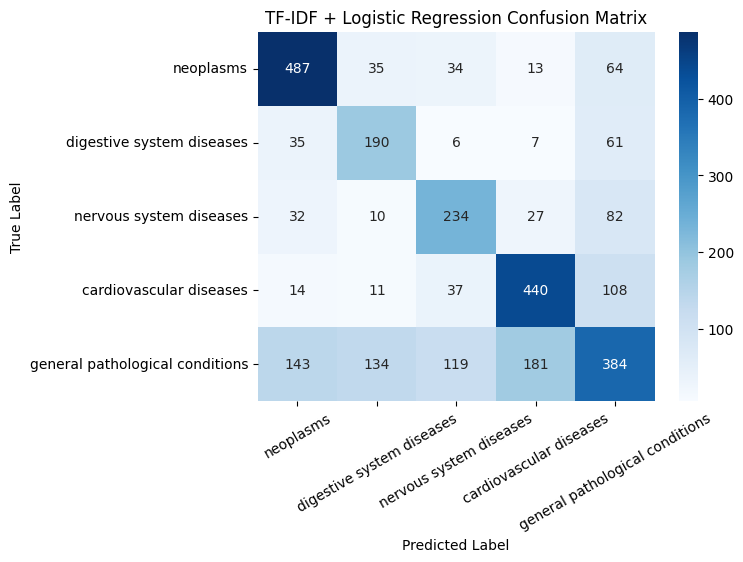

In [ ]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=class_order)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("TF-IDF + Logistic Regression Confusion Matrix")

plt.xticks(rotation=30)

plt.show()

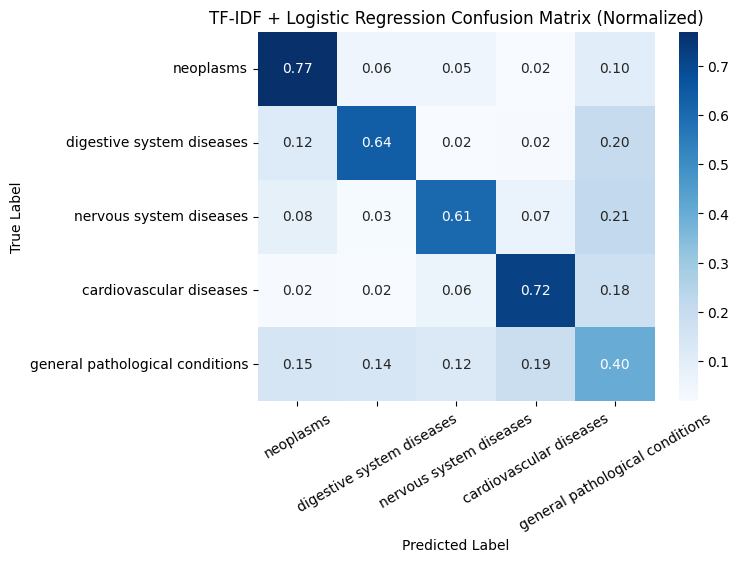

In [ ]:
# normalized confusion matrix
cm_norm = confusion_matrix(
    y_test,
    y_pred,
    labels=class_order,
    normalize="true"
)

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("TF-IDF + Logistic Regression Confusion Matrix (Normalized)")

plt.xticks(rotation=30)

plt.show()

In [ ]:
# important features
features = np.array(tfidf.get_feature_names_out())

for i, class_label in enumerate(lr.classes_):
    top_idx = np.argsort(lr.coef_[i])[-15:][::-1]
    top_features = features[top_idx]
    print(f"\ntop features for class {class_label} ({label_map[class_label]}):")
    print(", ".join(top_features))


top features for class 1 (neoplasms):
cancer, tumor, carcinoma, tumors, cell, leukemia, cells, melanoma, malignant, radiation, chemotherapy, breast, survival, metastases, cyst

top features for class 2 (digestive system diseases):
cirrhosis, liver, diarrhea, gallbladder, esophageal, bowel, hepatitis, hepatic, gastrointestinal, gastric, biliary, peritonitis, abdominal, ulcer, anal

top features for class 3 (nervous system diseases):
stroke, brain, cerebral, pain, headache, seizures, nerve, meningitis, migraine, sleep, intracranial, neurologic, motor, epilepsy, syncope

top features for class 4 (cardiovascular diseases):
hypertension, myocardial, heart, coronary, hypertensive, artery, aortic, cardiac, ischemia, blood pressure, cholesterol, ventricular, cardiovascular, endocarditis, pressure

top features for class 5 (general pathological conditions):
postoperative, chronic, acute, hemorrhage, recurrent, deletion, fistula, hyperplasia, infection, bleeding, airway, abscess, twins, infecti